# Plots mean MCS precipitation global map comparisons for multiple models
### The data is on the Cartesian lat/lon grid, produced by:
- PyFLEXTRKR/Analysis/calc_tbpf_mcs_monthly_rainmap.py
- combine_mcs_monthly_files.py

In [20]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
from scipy.ndimage import gaussian_filter
# import colorcet as cc
import copy, os
import colormaps as cmaps
import cartopy.crs as ccrs
import cartopy.feature as cf
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
%matplotlib inline

In [4]:
rootdir = "/pscratch/sd/w/wcmca1/hackathon/mcs/"
name_map = {
    'obs': 'OBS',
    'm1': 'ICON',
    'm2': 'IFS',
    'm3': 'NICAM',
    'm4': 'SCREAM',
    'm5': 'UM',
    'm6': 'CAS-ESM2',
}
dir_map = {
    'obs': 'IMERGv7',
    'm1': 'icon_d3hp003',
    'm2': 'ifs_tco3999_rcbmf',
    'm3': 'nicam_gl11',
    'm4': 'scream',
    'm5': 'um_glm_n2560_RAL3p3',
    'm6': 'casesm2_10km_nocumulus',
}

# Input filenames
filenames = {key:f'{rootdir}/{value}/stats/monthly/mcs_rainmap_monthly.nc' for key,value in dir_map.items()}

topfile = '/global/cfs/cdirs/m1867/zfeng/gpm/map_data/era5_orography.nc'
landmaskfile = '/pscratch/sd/f/feng045/DYAMOND/maps/IMERG_landmask_180W-180E_60S-60N.nc'

figdir = '/global/cfs/cdirs/m1867/zfeng/hk25/figures_mcs/'
os.makedirs(figdir, exist_ok=True)
print(figdir)

/global/cfs/cdirs/m1867/zfeng/hk25/figures_mcs/


### Check if input files exist

In [6]:
for key, value in filenames.items():
    print(f'{value}: {os.path.isfile(value)}')

/pscratch/sd/w/wcmca1/hackathon/mcs//IMERGv7/stats/monthly/mcs_rainmap_monthly.nc: True
/pscratch/sd/w/wcmca1/hackathon/mcs//icon_d3hp003/stats/monthly/mcs_rainmap_monthly.nc: True
/pscratch/sd/w/wcmca1/hackathon/mcs//ifs_tco3999_rcbmf/stats/monthly/mcs_rainmap_monthly.nc: True
/pscratch/sd/w/wcmca1/hackathon/mcs//nicam_gl11/stats/monthly/mcs_rainmap_monthly.nc: True
/pscratch/sd/w/wcmca1/hackathon/mcs//scream/stats/monthly/mcs_rainmap_monthly.nc: True
/pscratch/sd/w/wcmca1/hackathon/mcs//um_glm_n2560_RAL3p3/stats/monthly/mcs_rainmap_monthly.nc: True
/pscratch/sd/w/wcmca1/hackathon/mcs//casesm2_10km_nocumulus/stats/monthly/mcs_rainmap_monthly.nc: True


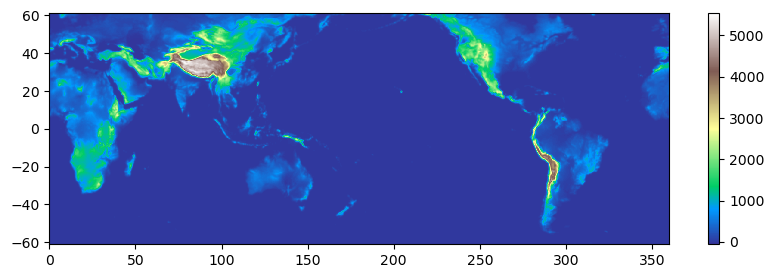

In [8]:
# Read topography data
dstop = xr.open_dataset(topfile)
# Convert surface geopotential to height in meters
ter = dstop.z.sel(latitude=slice(61,-61)).squeeze() / 9.80665
ter_s = gaussian_filter(ter, 1)
lon_ter = dstop.longitude
lat_ter = dstop.latitude.sel(latitude=slice(61,-61))

fig = plt.figure(figsize=[10,3], dpi=100)
plt.pcolormesh(lon_ter, lat_ter, ter_s, cmap='terrain')
plt.colorbar()

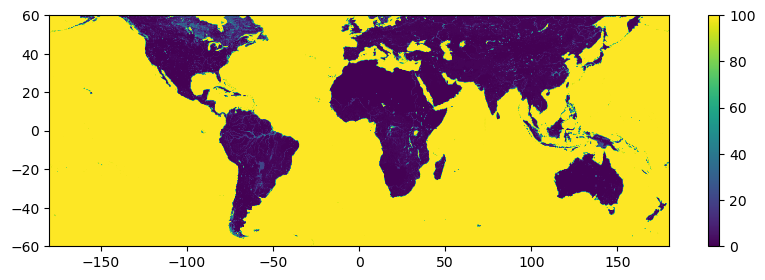

In [9]:
# Read landmask data
dslm = xr.open_dataset(landmaskfile)
lon_lm = dslm['lon']
lat_lm = dslm['lat']
    
landmask = dslm.landseamask
fig = plt.figure(figsize=[10,3], dpi=100)
plt.pcolormesh(lon_lm, lat_lm, landmask)
plt.colorbar()

## Read and combine all sources to a single DataSet

In [ ]:
drop_vars = ['latitude', 'longitude', 'lat', 'lon']
# Read all files and combine them with a new dimension 'source'
ds = xr.open_mfdataset(list(filenames.values()), combine='nested', concat_dim='source', drop_variables=drop_vars).squeeze()
# Assign new coordinate 'source' using name_map dictionary keys
ds['source'] = list(name_map.keys())
# Assign lat/lon coordinate from landmask
ds = ds.assign_coords({'lon': lon_lm, 'lat': lat_lm})
lon = ds.lon
lat = ds.lat
ds

<xarray.Dataset> Size: 10GB
Dimensions:                  (source: 7, time: 20, lat: 1200, lon: 3600)
Coordinates:
  * time                     (time) datetime64[ns] 160B 2019-08-01 ... 2021-0...
  * source                   (source) <U3 84B 'obs' 'm1' 'm2' ... 'm4' 'm5' 'm6'
  * lon                      (lon) float64 29kB -179.9 -179.8 ... 179.8 179.9
  * lat                      (lat) float64 10kB -59.95 -59.85 ... 59.85 59.95
Data variables:
    precipitation            (source, time, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 600, 1800), meta=np.ndarray>
    mcs_precipitation        (source, time, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 600, 1800), meta=np.ndarray>
    mcs_precipitation_count  (source, time, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 600, 1800), meta=np.ndarray>
    mcs_cloud_count          (source, time, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 600, 1800), meta=np.ndarray>
    ntimes                   (source, time) float32 560B dask.array<chunksize=(1, 12), meta=np.ndarray>
Attributes:
    title:       MCS precipitation accumulation
    contact:     Zhe Feng, zhe.feng@pnnl.gov
    created_on:  Thu Oct  9 16:36:52 2025

In [12]:
time_interval = 1

# Calculate total hours accounting for time interval
# ntimes is the number of timesteps, multiply by time_interval to get actual hours
ntimes = ds.ntimes.sum(dim='time')
nhours = ntimes * time_interval

# Sum monthly precipitation amount [mm], divided by total hours to get mm/day
tot_pcp_all = (24. * ds.precipitation.sum(dim='time') / nhours).compute()

In [22]:
print(f'Number of total hours for each source:')
for key in name_map.keys():
    print(f'{name_map[key]}: {int(nhours.sel(source=key).values.item())}')

# Precipitation amount [mm], divided by total number of hours to get [mm/h]
# then x24 to get [mm/day]
mcs_pcp_all = (24. * ds.mcs_precipitation.sum(dim='time') / nhours).compute()
# MCS precipitation fraction
mcs_pcpfrac_all = (100 * mcs_pcp_all / tot_pcp_all).compute()
# Number of hours with MCS precipitation/cloud
mcs_pcphours_all = ds.mcs_precipitation_count.sum(dim='time')
mcs_cloudhours_all = ds.mcs_cloud_count.sum(dim='time')
# MCS precipitation frequency
mcs_pcpfreq_all = (100 * (mcs_pcphours_all / nhours)).compute()
mcs_cloudfreq_all = (100 * (mcs_cloudhours_all / nhours)).compute()

Number of total hours for each source:
OBS: 9525
ICON: 8760
IFS: 10199
NICAM: 8759
SCREAM: 9455
UM: 9456
CAS-ESM2: 8760


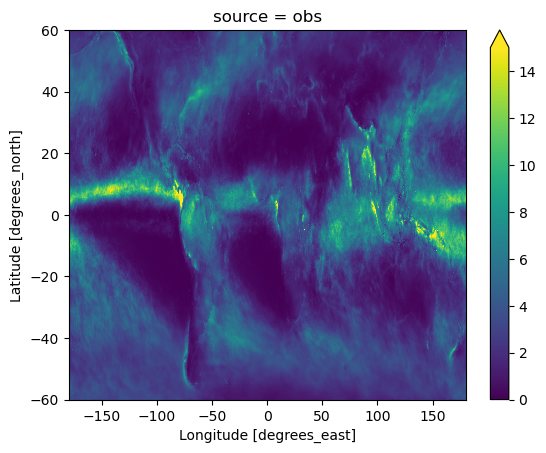

In [23]:
tot_pcp_all.sel(source='obs').plot(vmin=0, vmax=15)

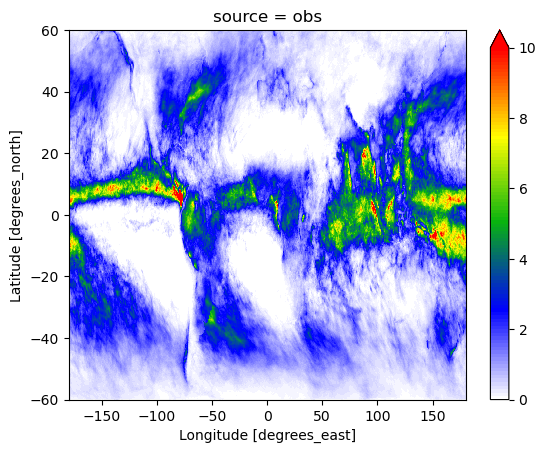

In [26]:
mcs_pcp_all.sel(source='obs').plot(vmin=0, vmax=10, cmap=cmaps.WhBlGrYeRe)

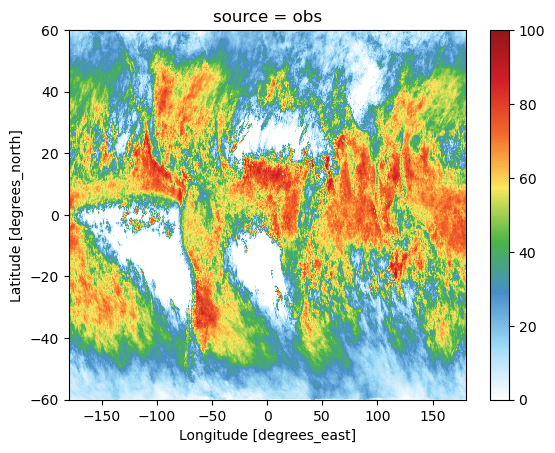

In [28]:
mcs_pcpfrac_all.sel(source='obs').plot(vmin=0, vmax=100, cmap=cmaps.WhiteBlueGreenYellowRed)

## Function to plot multiple maps

In [30]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """
    Truncate colormap.
    """
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

In [57]:
def plot_maps_grid(da_list, lon, lat, titles, levels, colormaps, cblabels, cbticks, figname, 
                  min_thresh=None, wspace=None, hspace=None, oob_colors=None, 
                  contourf=False, figsize=None, fontsize=None, cb_fontsize=None, 
                  show_cb2=False, figtitle=None, dpi=200, lat_lines=None):
    """
    Plot a grid of maps with flexible dimensions
    
    Parameters:
    -----------
    da_list : list of lists
        2D list of xarray DataArrays to plot, dimensions should be [nrow][ncol]
    lon, lat : 1D arrays
        Longitude and latitude arrays for the data
    titles : list of lists
        2D list of titles for each panel, dimensions should be [nrow][ncol]
    levels, colormaps, etc.: can be single values applied to all panels or lists of lists matching da_list
    lat_lines : list or None
        List of latitude values to plot as horizontal lines (e.g., [-20, 20] for tropics)
    """
    # Get grid dimensions from input data
    nrow = len(da_list)
    ncol = len(da_list[0]) if nrow > 0 else 0
    
    # Handle case where parameters might be the same for all panels
    def ensure_grid_format(param, param_name):
        if not isinstance(param, list):
            # If single value provided, apply to all panels
            return [[param for _ in range(ncol)] for _ in range(nrow)]
        elif isinstance(param, list):
            if len(param) == 0:
                # Empty list
                return [[[] for _ in range(ncol)] for _ in range(nrow)]
            elif isinstance(param[0], list):
                # Already a list of lists, return as is
                return param
            else:
                # It's a 1D list (like levels=[1,2,3,5,7,10]), use same list for all panels
                return [[param for _ in range(ncol)] for _ in range(nrow)]
        return param
    
    # Ensure all parameters have proper grid format
    colormaps = ensure_grid_format(colormaps, "colormaps")
    levels = ensure_grid_format(levels, "levels")
    cbticks = ensure_grid_format(cbticks, "cbticks")
    
    mpl.rcParams['font.size'] = fontsize
    map_extent = [0, 360, -60, 60]
    proj = ccrs.Robinson(central_longitude=225)
    data_proj = ccrs.PlateCarree()
    resolution = '110m'
    land = cf.NaturalEarthFeature('physical', 'land', resolution)
    ocean = cf.NaturalEarthFeature('physical', 'ocean', resolution)
    borders = cf.NaturalEarthFeature('cultural', 'admin_0_boundary_lines_land', resolution)

    fig = plt.figure(figsize=figsize, dpi=100)
    # Setup two columns (left: plots, right: colorbar)
    gs0 = gridspec.GridSpec(1, 2, figure=fig, height_ratios=[1], width_ratios=[1,0.02], wspace=0.05)
    # Setup panels to the left
    h_ratios = list(np.repeat(1, nrow))
    w_ratios = list(np.repeat(1, ncol))
    gs = gridspec.GridSpecFromSubplotSpec(nrow, ncol, subplot_spec=gs0[0], 
                                         height_ratios=h_ratios, width_ratios=w_ratios, 
                                         wspace=wspace, hspace=hspace)
    
    # Loop over each panel in the grid
    cf1 = None  # Will store the last plot for colorbar
    for row in range(nrow):
        for col in range(ncol):
            # Get panel index
            panel_idx = row * ncol + col

            # Get data for this panel
            Var = da_list[row][col]
            if Var is not None:
            
                # Create subplot
                ax = plt.subplot(gs[panel_idx], projection=proj)
                ax.set_global()
                ax.add_feature(land, facecolor='none', edgecolor='k', zorder=3)
                ax.set_aspect('auto', adjustable=None)
                
                # Add title
                flabel = ax.text(0.02, 0.94, titles[row][col], transform=ax.transAxes, fontsize=fontsize)
                flabel.set_bbox(dict(facecolor='w', alpha=0.8, edgecolor='w'))            
                
                # Apply minimum threshold if provided
                if min_thresh is not None:
                    Var = Var.where(Var > min_thresh)
                # Mask NAN data
                Var = np.ma.masked_where(np.isnan(Var), Var)
                
                # Setup colormap
                cmap = copy.copy(mpl.colormaps.get_cmap(colormaps[row][col]))
                
                # Set out-of-bounds colors
                if oob_colors is not None:
                    oob_c = oob_colors
                    if oob_c is not None:
                        cmap.set_over(oob_c['over'])
                        cmap.set_under(oob_c['under'])
                
                # Create color normalization
                norm = colors.BoundaryNorm(boundaries=levels[row][col], ncolors=cmap.N)
                
                # Plot data
                if not contourf:
                    cf1 = ax.pcolormesh(lon, lat, Var, shading='auto', norm=norm, cmap=cmap, transform=data_proj, zorder=2)
                else:
                    cf1 = ax.contourf(lon, lat, Var, levels=levels, norm=norm, cmap=cmap, transform=data_proj, extend='both', zorder=2)

                # Add gridlines
                # gl = ax.gridlines(crs=proj, draw_labels=False, linestyle='--', linewidth=0.5)
                
                # Add latitude lines if specified
                if lat_lines is not None:
                    for lat in lat_lines:
                        # Create longitude array spanning the globe
                        lons = np.linspace(-180, 180, 361)
                        lats = np.full_like(lons, lat)
                        ax.plot(lons, lats, color='k', linestyle='--', linewidth=1.5, 
                            transform=data_proj, zorder=4, alpha=0.8)
    
    # Add colorbar (using the last plotted data)
    if cf1 is not None:
        cax = plt.subplot(gs0[1])
        cbar = plt.colorbar(cf1, cax=cax, label=cblabels, ticks=cbticks[row][col], 
                           orientation='vertical', extend='both')
    
    # Add suptitle
    if figtitle:
        fig.suptitle(figtitle, y=0.92, fontweight='bold')
    
    # Save figure
    fig.savefig(figname, dpi=dpi, bbox_inches='tight', facecolor='w')
    return fig

/global/cfs/cdirs/m1867/zfeng/hk25/figures_mcs/globalmap_mcs_rainfrac_annual.png


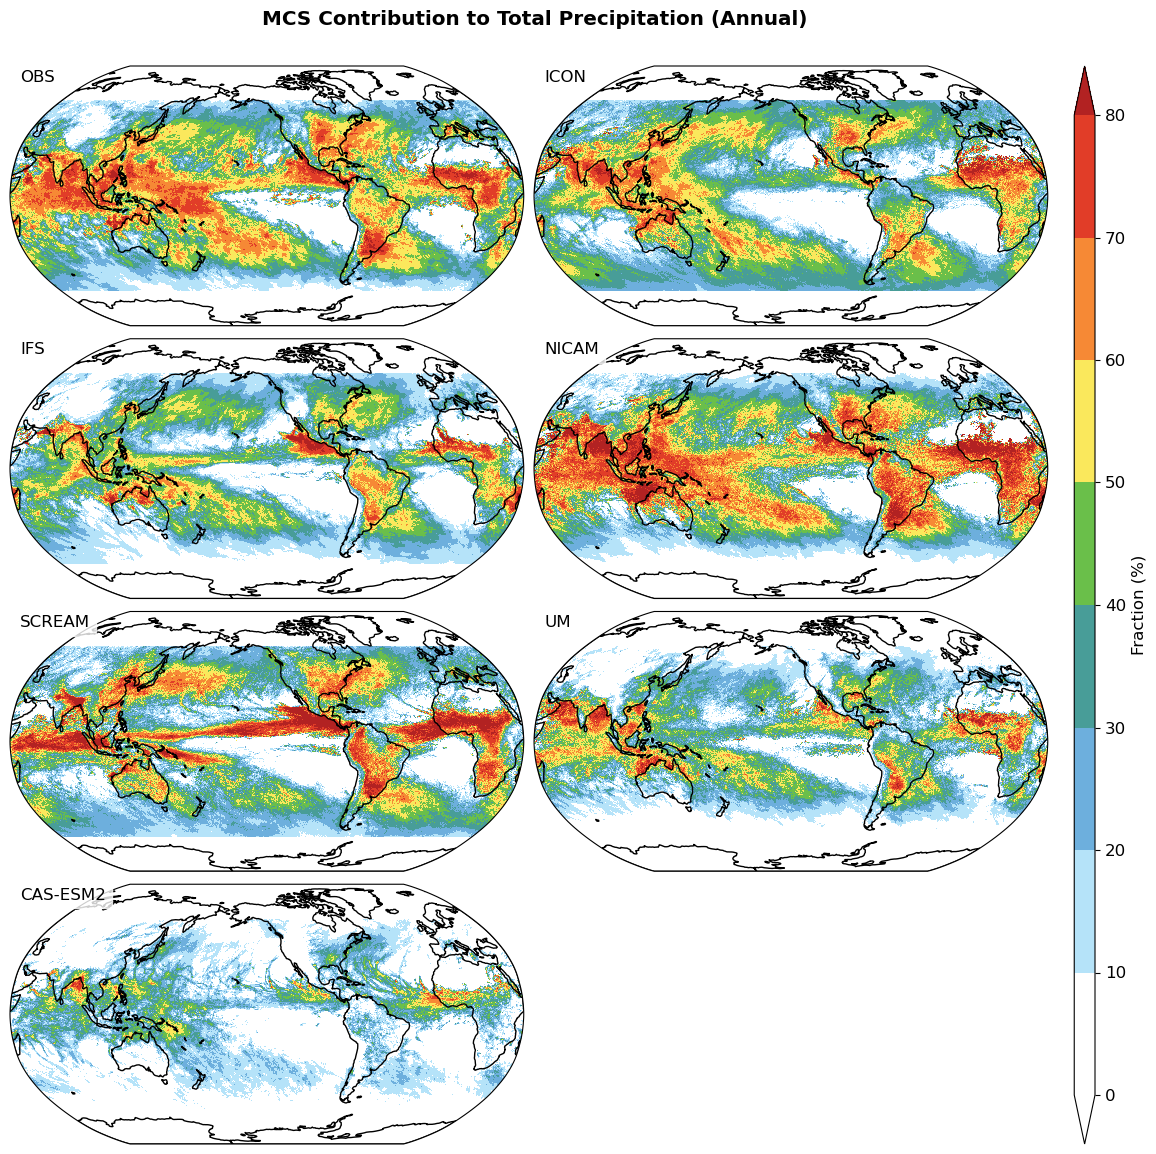

In [59]:
# Create 2D lists for data and titles
da_list = [
    [mcs_pcpfrac_all.sel(source='obs'), mcs_pcpfrac_all.sel(source='m1')],
    [mcs_pcpfrac_all.sel(source='m2'), mcs_pcpfrac_all.sel(source='m3')],
    [mcs_pcpfrac_all.sel(source='m4'), mcs_pcpfrac_all.sel(source='m5')],
    [mcs_pcpfrac_all.sel(source='m6'), None],
]
titles = [
    [f"{name_map['obs']}", f"{name_map['m1']}"],
    [f"{name_map['m2']}", f"{name_map['m3']}"],
    [f"{name_map['m4']}", f"{name_map['m5']}"],
    [f"{name_map['m6']}", None],
]

# Setup grid parameters
nrow = len(da_list)
ncol = len(da_list[0]) if nrow > 0 else 1
figwidth = 14
height_ratio_per_panel = 0.5
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth, figheight]
fontsize = 12
cb_fontsize = 10
wspace = 0.02
hspace = 0.05
varname1 = 'Fraction'
units = '%'
figtitle = 'MCS Contribution to Total Precipitation (Annual)'
lat_lines = None

# Setup levels and colormap
levels = np.arange(0, 81, 10)
min_thresh = None
colormaps = cmaps.WhiteBlueGreenYellowRed
colormaps = truncate_colormap(colormaps, minval=0.0, maxval=0.8)
cbticks = levels
oob_colors = {'over':'firebrick', 'under':'white'}
cblabels = f'{varname1} ({units})'
figname = f'{figdir}globalmap_mcs_rainfrac_annual.png'

# Plot figure
fig = plot_maps_grid(da_list, lon, lat, titles, levels, colormaps, cblabels, cbticks, figname,
                    figtitle=figtitle, lat_lines=lat_lines,
                    min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
                    fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
                    oob_colors=oob_colors, show_cb2=False, dpi=200)
print(figname)

/global/cfs/cdirs/m1867/zfeng/hk25/figures_mcs/globalmap_mcs_rain_annual.png


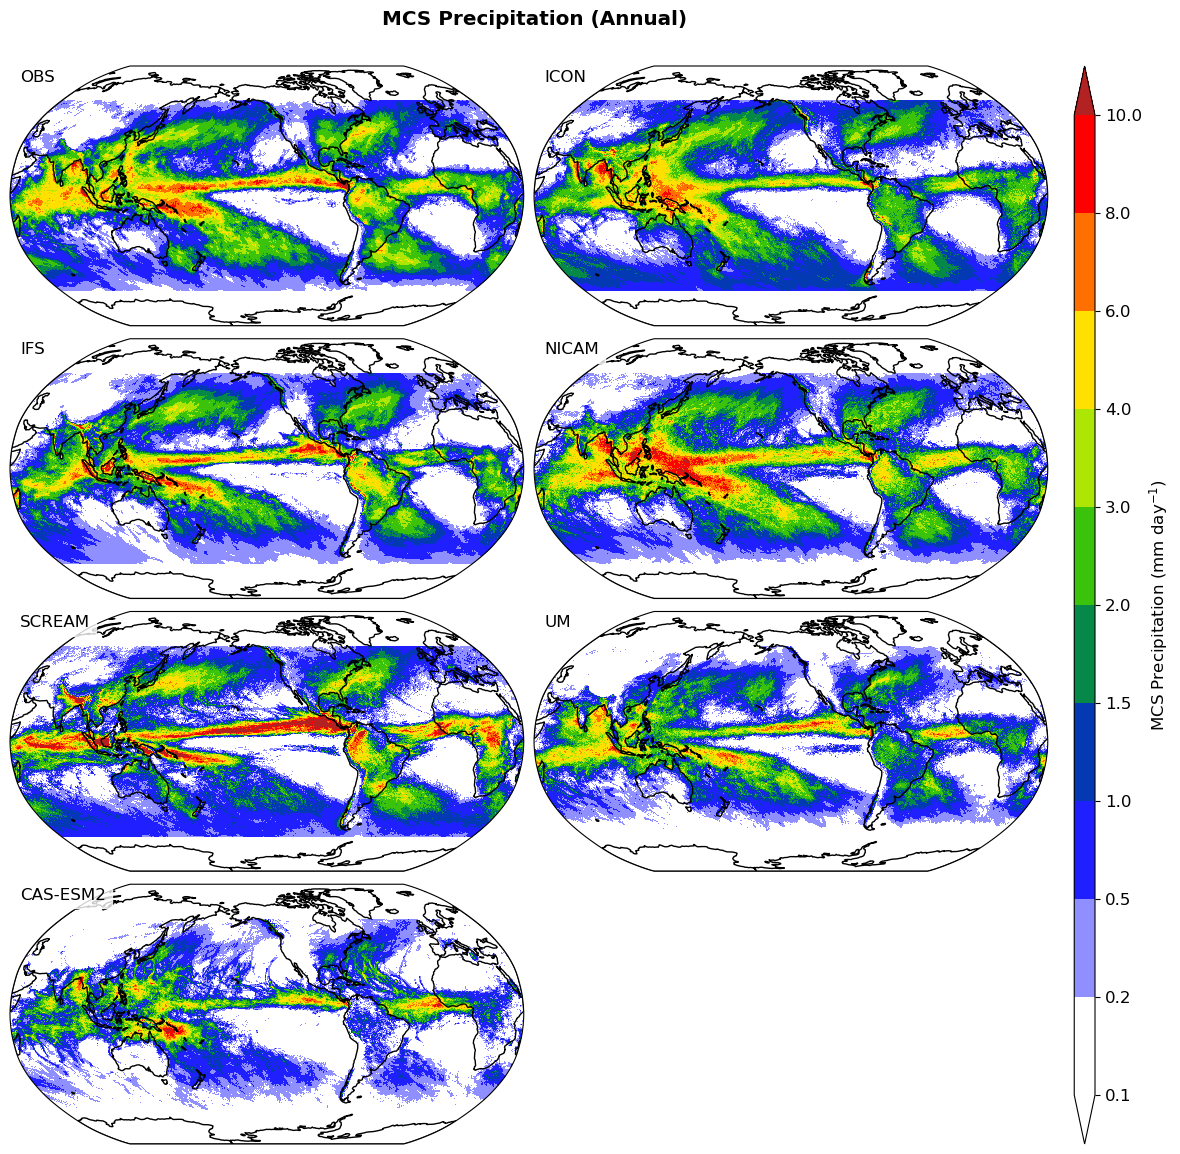

In [60]:
# Create 2D lists for data and titles
da_list = [
    [mcs_pcp_all.sel(source='obs'), mcs_pcp_all.sel(source='m1')],
    [mcs_pcp_all.sel(source='m2'), mcs_pcp_all.sel(source='m3')],
    [mcs_pcp_all.sel(source='m4'), mcs_pcp_all.sel(source='m5')],
    [mcs_pcp_all.sel(source='m6'), None],
]
titles = [
    [f"{name_map['obs']}", f"{name_map['m1']}"],
    [f"{name_map['m2']}", f"{name_map['m3']}"],
    [f"{name_map['m4']}", f"{name_map['m5']}"],
    [f"{name_map['m6']}", None],
]

# Setup grid parameters
nrow = len(da_list)
ncol = len(da_list[0]) if nrow > 0 else 1
figwidth = 14
height_ratio_per_panel = 0.5
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth, figheight]
fontsize = 12
cb_fontsize = 10
wspace = 0.02
hspace = 0.05
varname1 = 'MCS Precipitation'
units = 'mm day$^{-1}$'
figtitle = 'MCS Precipitation (Annual)'
lat_lines = None

# Setup levels and colormap
levels = [0.1,0.2,0.5,1,1.5,2,3,4,6,8,10]
min_thresh = None
colormaps = cmaps.WhBlGrYeRe
cbticks = levels
oob_colors = {'over':'firebrick', 'under':'white'}
cblabels = f'{varname1} ({units})'
figname = f'{figdir}globalmap_mcs_rain_annual.png'

# Plot figure
fig = plot_maps_grid(da_list, lon, lat, titles, levels, colormaps, cblabels, cbticks, figname,
                    figtitle=figtitle, lat_lines=lat_lines,
                    min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
                    fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
                    oob_colors=oob_colors, show_cb2=False, dpi=200)
print(figname)

/global/cfs/cdirs/m1867/zfeng/hk25/figures_mcs/globalmap_mcs_cloudfreq_annual.png


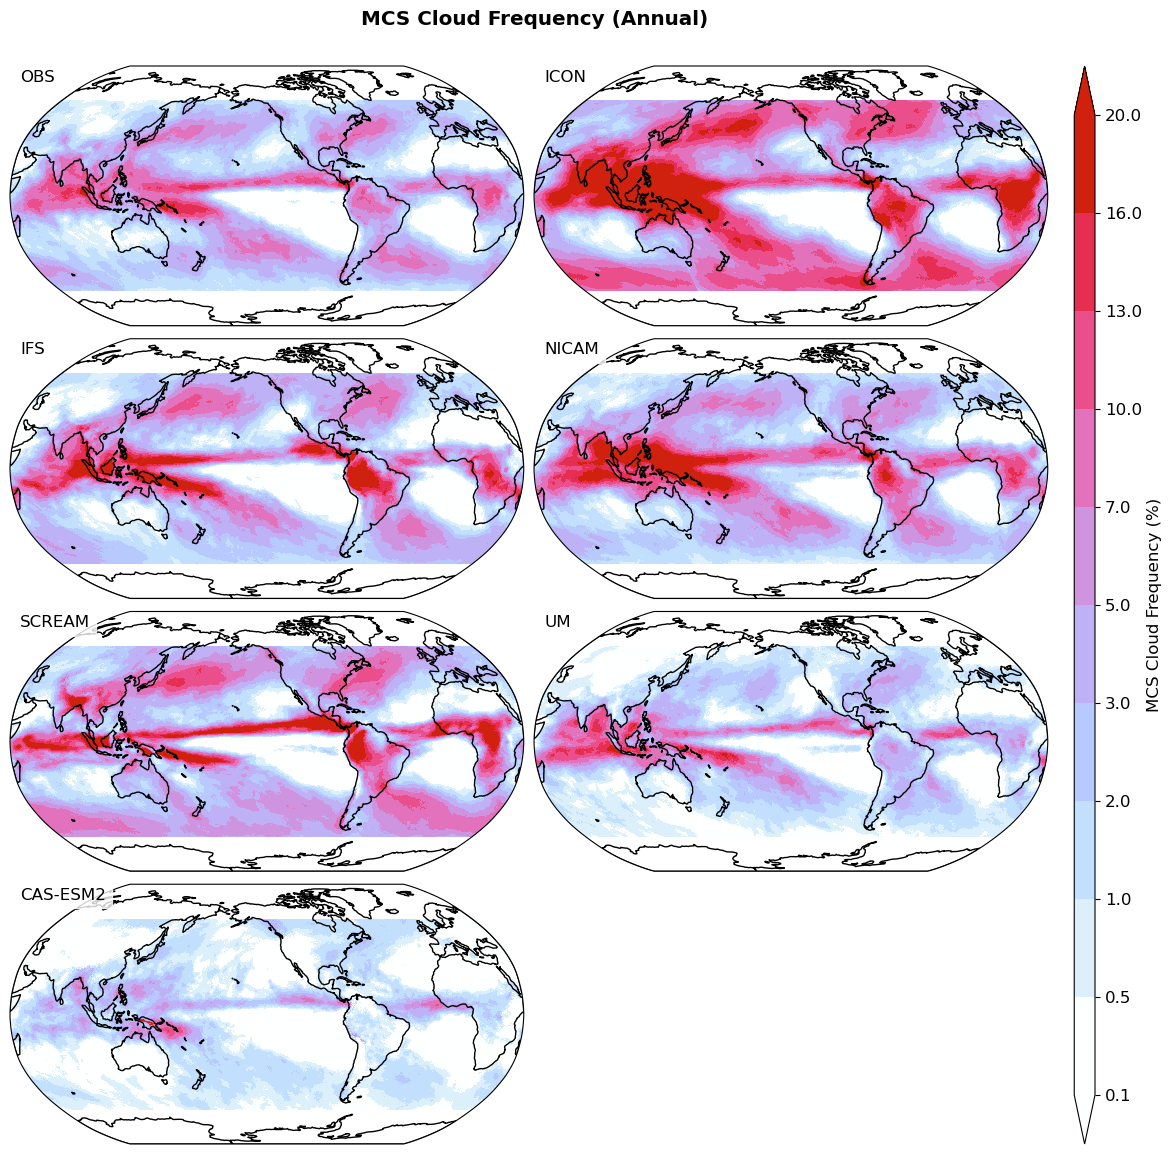

In [61]:
# Create 2D lists for data and titles
da_list = [
    [mcs_cloudfreq_all.sel(source='obs'), mcs_cloudfreq_all.sel(source='m1')],
    [mcs_cloudfreq_all.sel(source='m2'), mcs_cloudfreq_all.sel(source='m3')],
    [mcs_cloudfreq_all.sel(source='m4'), mcs_cloudfreq_all.sel(source='m5')],
    [mcs_cloudfreq_all.sel(source='m6'), None],
]
titles = [
    [f"{name_map['obs']}", f"{name_map['m1']}"],
    [f"{name_map['m2']}", f"{name_map['m3']}"],
    [f"{name_map['m4']}", f"{name_map['m5']}"],
    [f"{name_map['m6']}", None],
]

# Setup grid parameters
nrow = len(da_list)
ncol = len(da_list[0]) if nrow > 0 else 1
figwidth = 14
height_ratio_per_panel = 0.5
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth, figheight]
fontsize = 12
cb_fontsize = 10
wspace = 0.02
hspace = 0.05
varname1 = 'MCS Cloud Frequency'
units = '%'
figtitle = 'MCS Cloud Frequency (Annual)'
lat_lines = None

# Setup levels and colormap
levels = [0.1,0.5,1,2,3,5,7,10,13,16,20]
# levels = [0.1,0.2,0.4,0.6,1,1.5,2,3,4,6,8,10]
min_thresh = None
colormaps = cmaps.cet_l_wcmr
cbticks = levels
oob_colors = None
cblabels = f'{varname1} ({units})'
figname = f'{figdir}globalmap_mcs_cloudfreq_annual.png'

# Plot figure
fig = plot_maps_grid(da_list, lon, lat, titles, levels, colormaps, cblabels, cbticks, figname,
                    figtitle=figtitle, lat_lines=lat_lines,
                    min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
                    fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
                    oob_colors=oob_colors, show_cb2=False, dpi=200)
print(figname)

In [62]:
print(figname)

/global/cfs/cdirs/m1867/zfeng/hk25/figures_mcs/globalmap_mcs_cloudfreq_annual.png


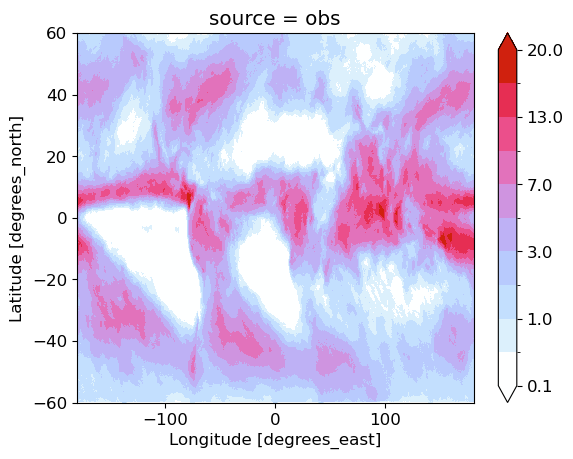

In [63]:
levels = [0.1,0.5,1,2,3,5,7,10,13,16,20]
norm = colors.BoundaryNorm(boundaries=levels, ncolors=cmaps.cet_l_wcmr.N)
mcs_cloudfreq_all.sel(source='obs').plot(norm=norm, cmap=cmaps.cet_l_wcmr)